In [47]:
!pip install face_recognition

**Importing libraries**

In [53]:
import cv2
import face_recognition
import numpy as np
from google.colab.patches import cv2_imshow

**Importing image path**

In [57]:
 # known person image
know_face_path="/content/modi_image.jpg"
# group image
unknow_know_face_path="/content/modi_putin.avif"

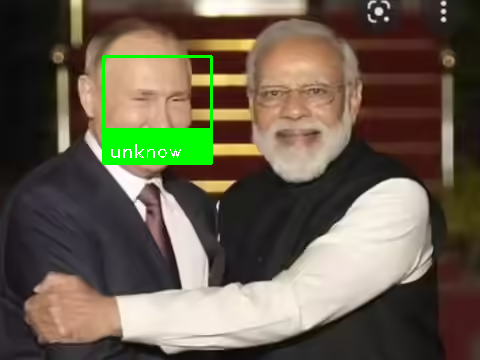

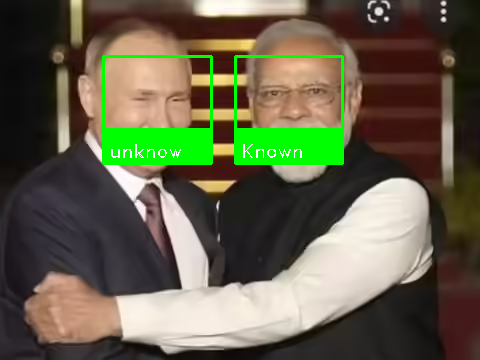

In [58]:
from face_recognition.api import face_locations
def face_recognization_system(know_face_path,unknow_know_face_path):
    know_face=face_recognition.load_image_file(know_face_path)

    know_face_encodings=face_recognition.face_encodings(know_face)

    if not know_face_encodings:
        print("[ERROR] No face found in the known reference image.")
        return

    bose_encoding=know_face_encodings[0]

    unknown_face=face_recognition.load_image_file(unknow_know_face_path)

    face_location=face_recognition.face_locations(unknown_face)

    face_encoding = face_recognition.face_encodings(unknown_face,face_location)

    display_image = cv2.cvtColor(unknown_face,cv2.COLOR_RGB2BGR)

    for (top,right,bottom,left),encoading in zip(face_location,face_encoding):
        matches= face_recognition.compare_faces([bose_encoding],encoading,tolerance=0.6)
        name="unknow"

        face_distanse=face_recognition.face_distance([bose_encoding],encoading)

        best_mach_index=np.argmin(face_distanse)

        if matches[best_mach_index]:
            name = "Known"
        color = (0, 255, 0) if name != "Unknown" else (0, 0, 255)
        cv2.rectangle(display_image, (left, top), (right, bottom), color, 2)

        cv2.rectangle(display_image, (left, bottom - 35), (right, bottom), color, cv2.FILLED)
        font = cv2.FONT_HERSHEY_DUPLEX
        cv2.putText(display_image, name, (left + 6, bottom - 6), font, 0.6, (255, 255, 255), 1)

        cv2_imshow(display_image)


face_recognization_system(know_face_path,unknow_know_face_path)
